# 2.0 Full EIP-7999 Three-Resource Equilibrium

This notebook extends the independent isoelastic demand estimates from notebook 1.8 to full EIP-7999. Execution, data, and state each have a separate base fee, so each fee is solved by requiring its resource demand to equal its own target.

The central capacity assumptions are:

- execution limits of 100M, 200M, and 450M gas, with targets at one half of the limit;
- data limits of 40M, 60M, and 90M gas, with targets at one quarter of the limit;
- a 75M state-gas target and no state-gas limit;
- the 35-day independent isoelastic estimates as central, with 21-, 60-, and 75-day estimates as robustness checks;
- a static-data anchor that removes the EIP-7623 floor and meters calldata, access lists, authorization tuples, and blob hashes at 16 gas per encoded byte;
- BAL gas induced mostly by execution/state-access activity, with only the directly state-creation-linked slice calibrated in notebook 1.11;
- no EIP-7918 reserve condition in this first equilibrium calculation; and
- the full-sample 120-day EIP-8038 + EIP-2780 refund-corrected execution multiplier from notebook 1.10.

The paired capacity packages are 100M execution/40M data, 200M execution/60M data, and the 450M execution/90M data scaling case. The 100M and 200M cases are the primary Glamsterdam comparisons; 450M is an exploratory scaling case. The 40M data limit is close to the 3-second `conservative_p90` capacity in notebook 0.2; the 60M and 90M limits are rounded versions of its 3-second `empirical_p90` capacities. The `glamsterdam_plus_8279` worst-case payload calculation is retained as a diagnostic; it does not replace the independent data limit under full 7999.

In [1]:
from itertools import product
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.titlesize": 18,
})
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from bandwidth_limits.propagation import CONSERVATIVE_P90, EMPIRICAL_P90, safe_payload_bytes
from bandwidth_limits.scenarios import GLAMSTERDAM_PLUS_8279
from bandwidth_limits.sweep import best_strategy_sweep
from basefee.eip7999_normalized import (
    ResourceFeeConfig,
    compute_base_fee,
    excess_gas_for_base_fee,
)

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_BASE_FEE_WEI = 1
RESOURCES = ["execution", "data", "state"]

ACCOUNTING_PANEL_CSV = DATA_DIR / f"daily_accounting_panel_calibrated_with_bal_{DATE_LABEL}.csv"
CURRENT_DATA_CSV = DATA_DIR / f"daily_current_data_gas_xatu_{DATE_LABEL}.csv"
EXECUTION_REPRICING_DAILY_CSV = DATA_DIR / f"execution_repricing_daily_{DATE_LABEL}.csv"
BAL_COUPLING_CSV = DATA_DIR / f"bal_state_creation_coupling_parameter_card_{DATE_LABEL}.csv"
ELASTICITY_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
G0_HEADLINE_CSV = DATA_DIR / f"three_way_equilibrium_headline_{DATE_LABEL}.csv"

OUT_CAPACITY_CSV = DATA_DIR / f"full_7999_equilibrium_capacity_card_{DATE_LABEL}.csv"
OUT_PAYLOAD_CHECK_CSV = DATA_DIR / f"full_7999_equilibrium_execution_payload_check_{DATE_LABEL}.csv"
OUT_ACCOUNTING_CSV = DATA_DIR / f"full_7999_equilibrium_accounting_card_{DATE_LABEL}.csv"
OUT_DATA_BRIDGE_CSV = DATA_DIR / f"full_7999_data_metering_bridge_{DATE_LABEL}.csv"
OUT_BAL_DRIVER_CSV = DATA_DIR / f"full_7999_bal_driver_calibration_{DATE_LABEL}.csv"
OUT_RESULTS_CSV = DATA_DIR / f"full_7999_equilibrium_results_{DATE_LABEL}.csv"
OUT_HEADLINE_CSV = DATA_DIR / f"full_7999_equilibrium_headline_{DATE_LABEL}.csv"
OUT_WINDOW_CSV = DATA_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.csv"


## Capacity Card

The propagation calculation and the execution worst-case calculation answer different questions.

1. The propagation fits ask how many payload bytes fit within the assumed propagation budget. At 16 data gas per byte, the 3-second `conservative_p90` full-window capacity is approximately 40.8M gas. The `empirical_p90` capacities are approximately 62.2M gas with a 0.75 safety factor and 89.9M gas with the full window. These motivate rounded 40M, 60M, and 90M data limits.
2. `glamsterdam_plus_8279` asks how many bytes can be induced by a full execution block under that Glamsterdam gas schedule. This is a diagnostic for the 100M, 200M, and 450M execution limits, not a full-7999 execution-to-bytes bound: the 64-gas-per-byte floors used by the check are deprecated in the full-7999 world modeled here. The separate data limit remains the authoritative payload bound. The 100M/40M, 200M/60M, and 450M/90M pairings are capacity packages chosen for comparison; propagation does not mechanically pair a data limit with an execution limit.

In [2]:
EXECUTION_LIMITS = [100_000_000, 200_000_000, 450_000_000]
DATA_LIMITS = [40_000_000, 60_000_000, 90_000_000]
STATE_TARGET = 75_000_000
EXECUTION_TARGET_RATIO = 2
DATA_TARGET_RATIO = 4
DATA_GAS_PER_BYTE = 16
PROPAGATION_WINDOW_MS = 3_000
PAIRED_DATA_LIMIT = {
    100_000_000: 40_000_000,
    200_000_000: 60_000_000,
    450_000_000: 90_000_000,
}

capacity_specs = [
    (CONSERVATIVE_P90, 1.00, 40_000_000),
    (EMPIRICAL_P90, 0.75, 60_000_000),
    (EMPIRICAL_P90, 1.00, 90_000_000),
]
capacity_rows = []
for propagation_fit, safety_factor, rounded_limit in capacity_specs:
    safe_bytes = safe_payload_bytes(
        PROPAGATION_WINDOW_MS, propagation_fit, safety_factor
    )
    exact_limit = DATA_GAS_PER_BYTE * safe_bytes
    capacity_rows.append({
        "propagation_fit": propagation_fit.name,
        "window_ms": PROPAGATION_WINDOW_MS,
        "safety_factor": safety_factor,
        "safe_payload_bytes": safe_bytes,
        "exact_data_gas_limit": exact_limit,
        "rounded_data_gas_limit": rounded_limit,
        "rounded_data_target": rounded_limit / DATA_TARGET_RATIO,
        "rounding_error_pct": 100 * (rounded_limit / exact_limit - 1),
    })
capacity_card = pd.DataFrame(capacity_rows)
capacity_card.to_csv(OUT_CAPACITY_CSV, index=False)
display(capacity_card)

payload_check = best_strategy_sweep(
    EXECUTION_LIMITS, [GLAMSTERDAM_PLUS_8279]
).copy()
payload_check["paired_data_gas_limit"] = payload_check["execution_gas_limit"].map(PAIRED_DATA_LIMIT)
payload_check["paired_data_byte_limit"] = payload_check["paired_data_gas_limit"] / DATA_GAS_PER_BYTE
payload_check["execution_implied_data_gas"] = payload_check["total_payload_bytes"] * DATA_GAS_PER_BYTE
payload_check["payload_pct_paired_data_limit"] = (
    payload_check["execution_implied_data_gas"] / payload_check["paired_data_gas_limit"]
)
payload_cols = [
    "execution_gas_limit", "schedule", "best_strategy",
    "total_payload_bytes", "total_payload_mib",
    "execution_implied_data_gas", "paired_data_gas_limit",
    "paired_data_byte_limit", "payload_pct_paired_data_limit",
]
payload_check[payload_cols].to_csv(OUT_PAYLOAD_CHECK_CSV, index=False)
display(payload_check[payload_cols])

,propagation_fit,window_ms,safety_factor,safe_payload_bytes,exact_data_gas_limit,rounded_data_gas_limit,rounded_data_target,rounding_error_pct
0,conservative_p90,3000,1.000000,2552761,40844176,40000000,"10,000,000.000000",-2.066821
1,empirical_p90,3000,0.750000,3885652,62170432,60000000,"15,000,000.000000",-3.491100
2,empirical_p90,3000,1.000000,5619286,89908576,90000000,"22,500,000.000000",0.101686


,execution_gas_limit,schedule,best_strategy,total_payload_bytes,total_payload_mib,execution_implied_data_gas,paired_data_gas_limit,paired_data_byte_limit,payload_pct_paired_data_limit
0,100000000,glamsterdam_plus_8279,all_calldata_nonzero,1562171,1.489802,24994736,40000000,"2,500,000.000000",0.624868
1,200000000,glamsterdam_plus_8279,all_calldata_nonzero,3124671,2.979918,49994736,60000000,"3,750,000.000000",0.833246
2,450000000,glamsterdam_plus_8279,all_calldata_nonzero,7030921,6.705209,112494736,90000000,"5,625,000.000000",1.249942


## 120-Day Demand And Metering Anchor

The demand elasticities were estimated using three historical gas-equivalent quantities. To transport those curves into 7999, the same physical activity is converted into each candidate resource's gas units.

For each resource, let $q_i^0$ be its historical gas-equivalent quantity and let $m_i$ convert that quantity into 7999 gas. The metered anchor is $g_i^0=m_iq_i^0$. A reference 7999 fee of $p_i^0=b_{\mathrm{ref}}/m_i$ preserves the historical effective price of that activity.

The [current EIP-7999 draft](https://eips.ethereum.org/EIPS/eip-7999) removes the EIP-7623 floor but retains calldata tokens, equivalent to 4 gas per zero byte and 16 per nonzero byte. This project's broader 8131/8279-style bandwidth scenario, specified in the [demand-model plan](../markdowns/demand_model_plan.md), instead meters every encoded byte at 16 gas and adds access-list, authorization-tuple, blob-hash, and eventually BAL bytes. The accounting bridge below reports both definitions so that the extension is not mistaken for the base EIP.

The static-data bridge uses exact Xatu calldata and blob-hash counts plus the existing sampled access-list and authorization-list calibrations. It does not make new RPC calls. BAL bytes are excluded from this metering multiplier because they are not independently demanded data. The equilibrium adds them as an induced output of execution/state-access activity plus a directly state-creation-linked slice calibrated in notebook 1.11.

In [3]:
accounting = pd.read_csv(ACCOUNTING_PANEL_CSV)
current_data = pd.read_csv(CURRENT_DATA_CSV)[
    ["date", "data_gas_current", "eip7623_data_uplift_proxy"]
]
execution_repricing = pd.read_csv(EXECUTION_REPRICING_DAILY_CSV)[[
    "date", "execution_current", "execution_8038_2780_refund_corrected",
]]
accounting = accounting.merge(current_data, on="date", how="left", validate="one_to_one")
accounting = accounting.merge(
    execution_repricing, on="date", how="left", validate="one_to_one"
)
required = [
    "data_gas_current", "eip7623_data_uplift_proxy", "execution_current",
    "execution_8038_2780_refund_corrected",
]
if accounting[required].isna().any().any():
    raise ValueError("A data or execution repricing input is missing")
if not np.allclose(
    accounting["data_gas_current"],
    accounting["standard_calldata_gas"] + accounting["eip7623_data_uplift_proxy"],
):
    raise ValueError("Current data gas does not reconcile to standard calldata gas plus EIP-7623 uplift")

blocks = float(accounting["block_count"].sum())
BASE_FEE_REF = float(accounting["median_base_fee_per_gas"].median())
current_data_total = float(accounting["data_gas_current"].sum())
current_state_total = float(accounting["current_state_creation_gas_calibrated"].sum())
current_execution_total = float(
    accounting["current_gas_used"].sum() - current_data_total - current_state_total
)
if not np.allclose(accounting["execution_current"].sum(), current_execution_total, rtol=1e-10, atol=1):
    raise ValueError("Execution repricing denominator does not match the three-resource anchor")

execution_7999_total = float(accounting["execution_8038_2780_refund_corrected"].sum())
data_base_7999_total = float(accounting["standard_calldata_gas"].sum())
data_flat16_calldata_total = float(16 * accounting["calldata_bytes"].sum())
data_blob_hash_total = float(16 * accounting["blob_versioned_hash_bytes"].sum())
data_access_list_total = float(16 * accounting["cal_tx_access_list_bytes"].sum())
data_authorization_total = float(16 * accounting["cal_authorization_tuple_8131_bytes"].sum())
data_7999_no_bal_total = (
    data_flat16_calldata_total + data_blob_hash_total
    + data_access_list_total + data_authorization_total
)
if not np.isclose(
    data_7999_no_bal_total, accounting["bandwidth_gas_16_calibrated_no_bal"].sum()
):
    raise ValueError("No-BAL bandwidth components do not reconcile")
bal_7999_total = float(DATA_GAS_PER_BYTE * accounting["bandwidth_bal_rlp_bytes"].sum())
data_7999_with_bal_total = data_7999_no_bal_total + bal_7999_total
state_7999_total = float(accounting["state_gas_8037_calibrated"].sum())
BAL_EXECUTION_GAS_RATIO = bal_7999_total / current_execution_total
BAL_BYTES_PER_MILLION_EXECUTION_GAS = BAL_EXECUTION_GAS_RATIO / DATA_GAS_PER_BYTE * 1_000_000

bal_coupling_card = pd.read_csv(BAL_COUPLING_CSV)
if len(bal_coupling_card) != 1 or bal_coupling_card.loc[0, "role"] != "strict_direct_entries":
    raise ValueError("BAL coupling parameter card must contain the one strict direct-entry estimate")
bal_coupling = bal_coupling_card.iloc[0]
BAL_STATE_CREATION_WEIGHT = float(bal_coupling["state_creation_weight"])
if not 0 <= BAL_STATE_CREATION_WEIGHT <= 1:
    raise ValueError("BAL direct state-linked weight is not a probability")
bal_driver_card = pd.DataFrame([{
    "anchor_days": len(accounting),
    "anchor_blocks": blocks,
    "bal_gas_per_block": bal_7999_total / blocks,
    "historical_execution_gas_per_block": current_execution_total / blocks,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "parent_driver": "execution quantity as access proxy plus direct state-creation entries",
    "bal_state_creation_weight_strict": BAL_STATE_CREATION_WEIGHT,
    "bal_state_weight_bootstrap_ci_2_5": float(bal_coupling["bootstrap_ci_2_5"]),
    "bal_state_weight_bootstrap_ci_97_5": float(bal_coupling["bootstrap_ci_97_5"]),
    "bal_state_weight_sample_blocks": int(bal_coupling["sample_blocks"]),
    "state_creation_weight_status": "direct-entry proxy calibrated in notebook 1.11",
}])
bal_driver_card.to_csv(OUT_BAL_DRIVER_CSV, index=False)
display(bal_driver_card.T)

bridge_specs = [
    ("current_eip7623", "current 4/16 calldata plus EIP-7623 floor uplift", current_data_total),
    ("base_eip7999_tx_data", "floor removed; calldata remains 4/16", data_base_7999_total),
    ("flat16_calldata", "project extension: all calldata bytes at 16 gas", data_flat16_calldata_total),
    ("plus_blob_hashes", "plus exact 32-byte blob versioned hashes", data_flat16_calldata_total + data_blob_hash_total),
    ("plus_access_lists", "plus existing sampled access-list RLP calibration", data_flat16_calldata_total + data_blob_hash_total + data_access_list_total),
    ("plus_authorizations_no_bal", "plus existing sampled authorization-tuple calibration; static anchor", data_7999_no_bal_total),
    ("plus_full_predicted_bal", "plus calibrated BAL size; reconciliation only", data_7999_with_bal_total),
]
data_bridge = pd.DataFrame(bridge_specs, columns=["scenario", "definition", "total_data_gas"])
data_bridge["data_gas_per_block"] = data_bridge["total_data_gas"] / blocks
data_bridge["multiplier_vs_current_eip7623"] = data_bridge["total_data_gas"] / current_data_total
data_bridge["incremental_gas_per_block"] = data_bridge["total_data_gas"].diff() / blocks
data_bridge["static_anchor_no_bal"] = data_bridge["scenario"].eq("plus_authorizations_no_bal")
data_bridge.to_csv(OUT_DATA_BRIDGE_CSV, index=False)
display(data_bridge)

ANCHOR_QUANTITIES = {
    "execution": current_execution_total / blocks,
    "data": current_data_total / blocks,
    "state": current_state_total / blocks,
}
METERING_MULTIPLIERS = {
    "execution": execution_7999_total / current_execution_total,
    "data": data_7999_no_bal_total / current_data_total,
    "state": state_7999_total / current_state_total,
}
ANCHOR_METERED_GAS = {
    name: ANCHOR_QUANTITIES[name] * METERING_MULTIPLIERS[name]
    for name in RESOURCES
}
REFERENCE_FEES_WEI = {
    name: BASE_FEE_REF / METERING_MULTIPLIERS[name]
    for name in RESOURCES
}

accounting_card = pd.DataFrame([{
    "start_date": accounting["date"].min(),
    "end_date": accounting["date"].max(),
    "days": len(accounting),
    "blocks": blocks,
    "historical_base_fee_ref_gwei": BASE_FEE_REF / GWEI,
    "execution_historical_quantity_per_block": ANCHOR_QUANTITIES["execution"],
    "data_historical_quantity_per_block": ANCHOR_QUANTITIES["data"],
    "state_historical_quantity_per_block": ANCHOR_QUANTITIES["state"],
    "execution_7999_gas_per_block": ANCHOR_METERED_GAS["execution"],
    "data_base_eip7999_4_16_per_block": data_base_7999_total / blocks,
    "data_flat16_calldata_per_block": data_flat16_calldata_total / blocks,
    "data_blob_hash_gas_per_block": data_blob_hash_total / blocks,
    "data_access_list_gas_per_block": data_access_list_total / blocks,
    "data_authorization_gas_per_block": data_authorization_total / blocks,
    "data_7999_gas_no_bal_per_block": data_7999_no_bal_total / blocks,
    "bal_7999_gas_per_block": bal_7999_total / blocks,
    "data_7999_gas_with_bal_per_block": data_7999_with_bal_total / blocks,
    "state_7999_gas_per_block": ANCHOR_METERED_GAS["state"],
    "execution_metering_multiplier": METERING_MULTIPLIERS["execution"],
    "data_metering_multiplier_no_bal": METERING_MULTIPLIERS["data"],
    "data_metering_multiplier_with_bal": data_7999_with_bal_total / current_data_total,
    "state_metering_multiplier": METERING_MULTIPLIERS["state"],
    "bal_share_of_data_gas_with_bal": bal_7999_total / data_7999_with_bal_total,
    "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
    "bal_bytes_per_million_historical_execution_gas": BAL_BYTES_PER_MILLION_EXECUTION_GAS,
    "bal_state_creation_weight_strict": BAL_STATE_CREATION_WEIGHT,
    "bal_state_weight_sample_blocks": int(bal_coupling["sample_blocks"]),
    "execution_reference_fee_gwei": REFERENCE_FEES_WEI["execution"] / GWEI,
    "data_reference_fee_gwei": REFERENCE_FEES_WEI["data"] / GWEI,
    "state_reference_fee_gwei": REFERENCE_FEES_WEI["state"] / GWEI,
}])
accounting_card.to_csv(OUT_ACCOUNTING_CSV, index=False)
display(accounting_card.T)

,0
anchor_days,120
anchor_blocks,"860,505.000000"
bal_gas_per_block,"2,118,028.130623"
historical_execution_gas_per_block,"23,942,241.363434"
bal_gas_per_historical_execution_gas,0.088464
bal_bytes_per_million_historical_execution_gas,"5,529.004413"
parent_driver,execution quantity as access proxy plus direct...
bal_state_creation_weight_strict,0.132676
bal_state_weight_bootstrap_ci_2_5,0.124803
bal_state_weight_bootstrap_ci_97_5,0.141094


,scenario,definition,total_data_gas,data_gas_per_block,multiplier_vs_current_eip7623,incremental_gas_per_block,static_anchor_no_bal
0,current_eip7623,current 4/16 calldata plus EIP-7623 floor uplift,"1,015,873,534,534.000000","1,180,555.063055",1.000000,NaN,False
1,base_eip7999_tx_data,floor removed; calldata remains 4/16,"888,840,106,060.000000","1,032,928.461845",0.874952,"-147,626.601210",False
2,flat16_calldata,project extension: all calldata bytes at 16 gas,"1,728,593,461,888.000000","2,008,812.803979",1.701583,"975,884.342134",False
3,plus_blob_hashes,plus exact 32-byte blob versioned hashes,"1,730,180,416,128.000000","2,010,657.016668",1.703145,"1,844.212689",False
4,plus_access_lists,plus existing sampled access-list RLP calibration,"1,809,281,359,201.515137","2,102,580.878904",1.781010,"91,923.862236",False
5,plus_authorizations_no_bal,plus existing sampled authorization-tuple cali...,"1,827,387,770,648.058838","2,123,622.489873",1.798834,"21,041.610969",True
6,plus_full_predicted_bal,plus calibrated BAL size; reconciliation only,"3,649,961,567,190.054688","4,241,650.620496",3.592929,"2,118,028.130623",False


,0
start_date,2026-02-01
end_date,2026-05-31
days,120
blocks,"860,505.000000"
historical_base_fee_ref_gwei,0.106928
execution_historical_quantity_per_block,"23,942,241.363434"
data_historical_quantity_per_block,"1,180,555.063055"
state_historical_quantity_per_block,"5,244,154.703798"
execution_7999_gas_per_block,"36,820,725.629258"
data_base_eip7999_4_16_per_block,"1,032,928.461845"


## Independent Isoelastic Elasticities

Notebook 1.8 recovers separate execution, data, and state elasticities from the clean 2025 gas-limit events. The 35-day estimates are central. All four available window lengths are retained here because the equilibrium fee can be very sensitive when an elasticity is small. No aggregate-plus-softmax result is used in this notebook.

In [4]:
elasticities = pd.read_csv(ELASTICITY_CSV).sort_values("window_days")
WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
CENTRAL_WINDOW = 35
if CENTRAL_WINDOW not in WINDOW_DAYS:
    raise ValueError("35-day elasticity calibration is missing")
if (elasticities[[f"eps_{name}" for name in RESOURCES]] <= 0).any().any():
    raise ValueError("All independent elasticities must be positive")
display(elasticities[[
    "window_days", "eps_agg", "eps_execution", "eps_data", "eps_state"
]])

,window_days,eps_agg,eps_execution,eps_data,eps_state
0,21,0.194893,0.117067,0.201790,0.478438
1,35,0.169292,0.121160,0.229476,0.334864
2,60,0.127086,0.081668,0.204691,0.279676
3,75,0.119173,0.078511,0.201391,0.253556


## Coupled Target-Clearing Equilibrium

Execution and state retain separate isoelastic demand curves. For either resource $i$, with metered anchor $g_i^0$, reference fee $p_i^0$, and elasticity $\epsilon_i$,

$$g_i(p_i)=g_i^0\left(\frac{p_i}{p_i^0}\right)^{-\epsilon_i},\qquad p_i^*=p_i^0\left(\frac{g_i^0}{T_i}\right)^{1/\epsilon_i}. $$

Data is decomposed into independently demanded static transaction content and BAL gas induced by parent activity:

$$D_{\mathrm{total}}(p_D)=D_{\mathrm{static},0}\left(\frac{p_D}{p_D^0}\right)^{-\epsilon_{\mathrm{static}}}+B_0\left[(1-w_S)\frac{A^*}{A_0}+w_S\frac{S^*}{S_0}\right]\left(\frac{p_D}{p_D^0}\right)^{-\gamma_{\mathrm{BAL}}}. $$

$A$ is state-access activity and $S$ is persistent state creation. Historical data do not provide an independently priced access index, so the available physical execution quantity $E^*=T_E/m_E$ is used as the reduced-form proxy for $A^*$. The state quantity is $S^*=T_S/m_S$.

Notebook 1.11 estimates only the BAL entries directly linked to newly created slots, accounts, and code. The retained strict weight is $w_S=0.130$; the remaining 87.0% stays with the execution/access proxy. The weights partition the baseline BAL and do not double count it. We set $\gamma_{\mathrm{BAL}}=0$, and solve the data fee from $D_{\mathrm{total}}(p_D^*)=T_D$.

The EIP-4844-style fake exponential determines how the protocol moves toward each fee and maps excess gas to integer wei. We report the continuous solution and the nearest represented protocol fee.


In [5]:
def resource_config(resource, execution_limit, data_limit):
    if resource == "execution":
        return ResourceFeeConfig(
            name=resource, gas_limit=int(execution_limit),
            gas_target=int(execution_limit // EXECUTION_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    if resource == "data":
        return ResourceFeeConfig(
            name=resource, gas_limit=int(data_limit),
            gas_target=int(data_limit // DATA_TARGET_RATIO),
            min_base_fee=MIN_BASE_FEE_WEI, reserve_mode="none",
        )
    if resource == "state":
        return ResourceFeeConfig(
            name=resource, gas_limit=None, gas_target=STATE_TARGET,
            normalization_denominator=STATE_TARGET,
            min_base_fee=MIN_BASE_FEE_WEI,
        )
    raise ValueError(resource)


def metered_demand(base_fee_wei, *, anchor_metered_gas, reference_fee_wei, elasticity):
    return anchor_metered_gas * (base_fee_wei / reference_fee_wei) ** (-elasticity)


def nearest_protocol_fee(continuous_fee_wei, *, config, anchor_metered_gas, reference_fee_wei, elasticity):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        usage = metered_demand(
            represented_fee, anchor_metered_gas=anchor_metered_gas,
            reference_fee_wei=reference_fee_wei, elasticity=elasticity,
        )
        candidates.append({
            "protocol_base_fee_wei": represented_fee,
            "warm_start_excess_gas": excess,
            "metered_at_protocol_fee": usage,
            "absolute_target_error": abs(usage - config.gas_target),
        })
    return min(candidates, key=lambda row: row["absolute_target_error"])


def solve_resource(*, resource, elasticity, execution_limit, data_limit,
                   anchor_quantity=None, metering_multiplier=None):
    config = resource_config(resource, execution_limit, data_limit)
    q0 = ANCHOR_QUANTITIES[resource] if anchor_quantity is None else float(anchor_quantity)
    multiplier = (METERING_MULTIPLIERS[resource]
                  if metering_multiplier is None else float(metering_multiplier))
    anchor_metered = q0 * multiplier
    reference_fee = BASE_FEE_REF / multiplier
    continuous_fee = reference_fee * (anchor_metered / config.gas_target) ** (1 / elasticity)
    continuous_metered = metered_demand(
        continuous_fee, anchor_metered_gas=anchor_metered,
        reference_fee_wei=reference_fee, elasticity=elasticity,
    )
    protocol = nearest_protocol_fee(
        continuous_fee, config=config, anchor_metered_gas=anchor_metered,
        reference_fee_wei=reference_fee, elasticity=elasticity,
    )
    return {
        "resource": resource,
        "gas_limit": config.gas_limit,
        "gas_target": config.gas_target,
        "elasticity": elasticity,
        "anchor_historical_quantity": q0,
        "metering_multiplier": multiplier,
        "anchor_metered_gas": anchor_metered,
        "reference_base_fee_gwei": reference_fee / GWEI,
        "equilibrium_base_fee_wei_continuous": continuous_fee,
        "equilibrium_base_fee_gwei": continuous_fee / GWEI,
        "effective_equilibrium_fee_gwei": multiplier * continuous_fee / GWEI,
        "metered_at_continuous_fee": continuous_metered,
        "continuous_target_error_pct": 100 * (continuous_metered / config.gas_target - 1),
        "minimum_fee_binding": continuous_fee < MIN_BASE_FEE_WEI,
        "protocol_base_fee_wei": protocol["protocol_base_fee_wei"],
        "protocol_base_fee_gwei": protocol["protocol_base_fee_wei"] / GWEI,
        "protocol_fee_at_minimum": protocol["protocol_base_fee_wei"] == MIN_BASE_FEE_WEI,
        "warm_start_excess_gas": protocol["warm_start_excess_gas"],
        "metered_at_protocol_fee": protocol["metered_at_protocol_fee"],
        "protocol_target_error_pct": 100 * (protocol["metered_at_protocol_fee"] / config.gas_target - 1),
        "equilibrium_exists": True,
        "infeasible_reason": None,
    }


def coupled_data_components(
    base_fee_wei, *, static_anchor_gas, reference_fee_wei, static_elasticity,
    bal_anchor_gas, bal_parent_activity_ratio, bal_price_elasticity,
):
    price_ratio = base_fee_wei / reference_fee_wei
    static_gas = static_anchor_gas * price_ratio ** (-static_elasticity)
    bal_gas = (
        bal_anchor_gas * bal_parent_activity_ratio
        * price_ratio ** (-bal_price_elasticity)
    )
    return static_gas, bal_gas, static_gas + bal_gas


def nearest_protocol_fee_coupled_data(continuous_fee_wei, *, config, demand_fn):
    lower = max(MIN_BASE_FEE_WEI, math.floor(continuous_fee_wei))
    upper = max(MIN_BASE_FEE_WEI, math.ceil(continuous_fee_wei))
    candidates = []
    for requested_fee in sorted({lower, upper}):
        excess = excess_gas_for_base_fee(int(requested_fee), config)
        represented_fee = compute_base_fee(excess, config)
        static_gas, bal_gas, total_gas = demand_fn(represented_fee)
        candidates.append({
            "protocol_base_fee_wei": represented_fee,
            "warm_start_excess_gas": excess,
            "metered_at_protocol_fee": total_gas,
            "static_at_protocol_fee": static_gas,
            "bal_at_protocol_fee": bal_gas,
            "absolute_target_error": abs(total_gas - config.gas_target),
        })
    return min(candidates, key=lambda row: row["absolute_target_error"])


def solve_coupled_data(*, static_elasticity, bal_price_elasticity,
                       execution_target, state_target, execution_limit, data_limit,
                       bal_state_creation_weight=BAL_STATE_CREATION_WEIGHT):
    config = resource_config("data", execution_limit, data_limit)
    static_anchor = ANCHOR_METERED_GAS["data"]
    bal_anchor = bal_7999_total / blocks
    reference_fee = REFERENCE_FEES_WEI["data"]
    execution_physical = execution_target / METERING_MULTIPLIERS["execution"]
    execution_access_ratio = execution_physical / ANCHOR_QUANTITIES["execution"]
    state_physical = state_target / METERING_MULTIPLIERS["state"]
    state_physical_ratio = state_physical / ANCHOR_QUANTITIES["state"]
    bal_parent_activity_ratio = (
        (1 - bal_state_creation_weight) * execution_access_ratio
        + bal_state_creation_weight * state_physical_ratio
    )

    def demand_fn(base_fee_wei):
        return coupled_data_components(
            base_fee_wei, static_anchor_gas=static_anchor,
            reference_fee_wei=reference_fee, static_elasticity=static_elasticity,
            bal_anchor_gas=bal_anchor, bal_parent_activity_ratio=bal_parent_activity_ratio,
            bal_price_elasticity=bal_price_elasticity,
        )

    induced_bal_at_reference_mix = bal_anchor * bal_parent_activity_ratio
    common = {
        "execution_physical_quantity_driver": execution_physical,
        "execution_access_proxy_ratio_to_anchor": execution_access_ratio,
        "execution_physical_ratio_to_anchor": execution_access_ratio,
        "state_physical_quantity_driver": state_physical,
        "state_physical_ratio_to_anchor": state_physical_ratio,
        "bal_parent_activity_ratio": bal_parent_activity_ratio,
        "bal_state_creation_weight": bal_state_creation_weight,
        "bal_execution_state_access_weight": 1 - bal_state_creation_weight,
        "bal_price_elasticity": bal_price_elasticity,
        "bal_gas_per_historical_execution_gas": BAL_EXECUTION_GAS_RATIO,
        "bal_parent_driver": "execution_quantity_as_access_proxy_plus_direct_state_creation",
        "state_creation_weight_status": "direct-entry proxy calibrated in notebook 1.11",
    }
    if bal_price_elasticity == 0 and induced_bal_at_reference_mix >= config.gas_target:
        return {
            "resource": "data", "gas_limit": config.gas_limit,
            "gas_target": config.gas_target, "elasticity": static_elasticity,
            "anchor_historical_quantity": ANCHOR_QUANTITIES["data"],
            "metering_multiplier": METERING_MULTIPLIERS["data"],
            "anchor_metered_gas": static_anchor,
            "reference_base_fee_gwei": reference_fee / GWEI,
            "equilibrium_base_fee_wei_continuous": np.nan,
            "equilibrium_base_fee_gwei": np.nan,
            "effective_equilibrium_fee_gwei": np.nan,
            "metered_at_continuous_fee": induced_bal_at_reference_mix,
            "continuous_target_error_pct": 100 * (induced_bal_at_reference_mix / config.gas_target - 1),
            "minimum_fee_binding": False,
            "protocol_base_fee_wei": np.nan, "protocol_base_fee_gwei": np.nan,
            "protocol_fee_at_minimum": False, "warm_start_excess_gas": np.nan,
            "metered_at_protocol_fee": np.nan, "protocol_target_error_pct": np.nan,
            "static_data_gas_at_equilibrium": 0.0,
            "bal_data_gas_at_equilibrium": induced_bal_at_reference_mix,
            "bal_share_of_data_target": induced_bal_at_reference_mix / config.gas_target,
            **common,
            "equilibrium_exists": False,
            "infeasible_reason": "parent-activity-induced BAL gas reaches data target at gamma_BAL=0",
        }
    low_log_ratio, high_log_ratio = -80.0, 80.0
    for _ in range(240):
        mid_log_ratio = (low_log_ratio + high_log_ratio) / 2
        candidate_fee = reference_fee * math.exp(mid_log_ratio)
        if demand_fn(candidate_fee)[2] > config.gas_target:
            low_log_ratio = mid_log_ratio
        else:
            high_log_ratio = mid_log_ratio
    continuous_fee = reference_fee * math.exp((low_log_ratio + high_log_ratio) / 2)
    static_gas, bal_gas, total_gas = demand_fn(continuous_fee)
    protocol = nearest_protocol_fee_coupled_data(
        continuous_fee, config=config, demand_fn=demand_fn
    )
    return {
        "resource": "data",
        "gas_limit": config.gas_limit,
        "gas_target": config.gas_target,
        "elasticity": static_elasticity,
        "anchor_historical_quantity": ANCHOR_QUANTITIES["data"],
        "metering_multiplier": METERING_MULTIPLIERS["data"],
        "anchor_metered_gas": static_anchor,
        "reference_base_fee_gwei": reference_fee / GWEI,
        "equilibrium_base_fee_wei_continuous": continuous_fee,
        "equilibrium_base_fee_gwei": continuous_fee / GWEI,
        "effective_equilibrium_fee_gwei": METERING_MULTIPLIERS["data"] * continuous_fee / GWEI,
        "metered_at_continuous_fee": total_gas,
        "continuous_target_error_pct": 100 * (total_gas / config.gas_target - 1),
        "minimum_fee_binding": continuous_fee < MIN_BASE_FEE_WEI,
        "protocol_base_fee_wei": protocol["protocol_base_fee_wei"],
        "protocol_base_fee_gwei": protocol["protocol_base_fee_wei"] / GWEI,
        "protocol_fee_at_minimum": protocol["protocol_base_fee_wei"] == MIN_BASE_FEE_WEI,
        "warm_start_excess_gas": protocol["warm_start_excess_gas"],
        "metered_at_protocol_fee": protocol["metered_at_protocol_fee"],
        "protocol_target_error_pct": 100 * (protocol["metered_at_protocol_fee"] / config.gas_target - 1),
        "static_data_gas_at_equilibrium": static_gas,
        "bal_data_gas_at_equilibrium": bal_gas,
        "bal_share_of_data_target": bal_gas / config.gas_target,
        **common,
        "equilibrium_exists": True,
        "infeasible_reason": None,
    }


BAL_DATA_PRICE_ELASTICITY = 0.0
rows = []
for _, calibration in elasticities.iterrows():
    window_days = int(calibration["window_days"])
    for execution_limit, data_limit in product(EXECUTION_LIMITS, DATA_LIMITS):
        scenario = f"E{execution_limit//1_000_000}_D{data_limit//1_000_000}_S{STATE_TARGET//1_000_000}"
        paired = PAIRED_DATA_LIMIT[execution_limit] == data_limit
        execution_row = solve_resource(
            resource="execution", elasticity=float(calibration["eps_execution"]),
            execution_limit=execution_limit, data_limit=data_limit,
        )
        state_row = solve_resource(
            resource="state", elasticity=float(calibration["eps_state"]),
            execution_limit=execution_limit, data_limit=data_limit,
        )
        data_row = solve_coupled_data(
            static_elasticity=float(calibration["eps_data"]),
            bal_price_elasticity=BAL_DATA_PRICE_ELASTICITY,
            execution_target=execution_row["gas_target"],
            state_target=state_row["gas_target"],
            execution_limit=execution_limit, data_limit=data_limit,
            bal_state_creation_weight=BAL_STATE_CREATION_WEIGHT,
        )
        for row in [execution_row, data_row, state_row]:
            row.update({
                "scenario": scenario, "paired_capacity_scenario": paired,
                "window_days": window_days,
                "execution_gas_limit": execution_limit,
                "data_gas_limit": data_limit,
                "state_gas_target": STATE_TARGET,
                "execution_metering_source": "120_day_total_ratio_8038_2780_refund_corrected",
                "data_metering_scenario": "static_flat16_plus_access_state_induced_bal",
            })
            rows.append(row)
results = pd.DataFrame(rows)

feasible_results = results[results["equilibrium_exists"]]
if not np.allclose(feasible_results["metered_at_continuous_fee"], feasible_results["gas_target"], rtol=1e-10):
    raise AssertionError("Continuous equilibrium does not clear every resource target")
for window_days in WINDOW_DAYS:
    check = results[results["window_days"].eq(window_days)]
    if check[check["resource"].eq("execution")].groupby("execution_gas_limit")["equilibrium_base_fee_gwei"].nunique().max() != 1:
        raise AssertionError("Execution fee should not depend on the data limit")
    if check[check["resource"].eq("state")]["equilibrium_base_fee_gwei"].nunique() != 1:
        raise AssertionError("State fee should not depend on execution or data limits")
results.to_csv(OUT_RESULTS_CSV, index=False)
print("solved", results.shape, "resource equilibria")
print("no target-clearing equilibrium:", int((~results["equilibrium_exists"]).sum()))
print("continuous minimum-fee cases:", int(results["minimum_fee_binding"].sum()))
print("nearest protocol fee equals 1 wei:", int(results["protocol_fee_at_minimum"].sum()))

solved (108, 45) resource equilibria
no target-clearing equilibrium: 4
continuous minimum-fee cases: 6
nearest protocol fee equals 1 wei: 6


## Central Full-7999 Equilibrium And Glamsterdam Bridge

The headline table uses the paired 100M-execution/40M-data, 200M-execution/60M-data, and 450M-execution/90M-data capacity packages with the 35-day elasticities. Static data uses $\epsilon_{\mathrm{static}}=0.229$. BAL gas uses the execution/access proxy and state quantities needed to clear their targets, with the notebook-1.11 strict direct state-creation weight $w_S=0.130$ and $\gamma_{\mathrm{BAL}}=0$. The first two cases are placed beside the corresponding shared Glamsterdam equilibrium fee from notebook 1.9.

This is a parameter bridge, not yet an economic ranking. Glamsterdam has one target on `max(regular, state)`, whereas full 7999 clears three targets simultaneously. The data condition now depends on execution capacity and, more modestly, on the state target through directly linked BAL entries. Raw base fees also price different gas units. Effective transaction-bundle costs and fee dynamics belong in the next comparison notebook.


In [6]:
central = results[
    results["window_days"].eq(CENTRAL_WINDOW)
    & results["paired_capacity_scenario"]
].copy()
fee_wide = central.pivot(index=[
    "scenario", "execution_gas_limit", "data_gas_limit", "state_gas_target"
], columns="resource", values="equilibrium_base_fee_gwei").reset_index()
fee_wide = fee_wide.rename(columns={
    "execution": "execution_target_clearing_fee_gwei_continuous",
    "data": "data_target_clearing_fee_gwei_continuous",
    "state": "state_target_clearing_fee_gwei_continuous",
})
effective_wide = central.pivot(
    index="scenario", columns="resource", values="effective_equilibrium_fee_gwei"
).reset_index().rename(columns={
    "execution": "execution_effective_fee_gwei",
    "data": "data_effective_fee_gwei",
    "state": "state_effective_fee_gwei",
})
protocol_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_base_fee_wei"
).reset_index().rename(columns={
    "execution": "execution_protocol_base_fee_wei",
    "data": "data_protocol_base_fee_wei",
    "state": "state_protocol_base_fee_wei",
})
protocol_gwei_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_base_fee_gwei"
).reset_index().rename(columns={
    "execution": "execution_protocol_base_fee_gwei",
    "data": "data_protocol_base_fee_gwei",
    "state": "state_protocol_base_fee_gwei",
})
floor_wide = central.pivot(
    index="scenario", columns="resource", values="minimum_fee_binding"
).reset_index().rename(columns={
    "execution": "execution_target_unreachable_at_minimum_fee",
    "data": "data_target_unreachable_at_minimum_fee",
    "state": "state_target_unreachable_at_minimum_fee",
})
protocol_error_wide = central.pivot(
    index="scenario", columns="resource", values="protocol_target_error_pct"
).reset_index().rename(columns={
    "execution": "execution_protocol_target_error_pct",
    "data": "data_protocol_target_error_pct",
    "state": "state_protocol_target_error_pct",
})
headline = (
    fee_wide.merge(effective_wide, on="scenario", validate="one_to_one")
    .merge(protocol_wide, on="scenario", validate="one_to_one")
    .merge(protocol_gwei_wide, on="scenario", validate="one_to_one")
    .merge(floor_wide, on="scenario", validate="one_to_one")
    .merge(protocol_error_wide, on="scenario", validate="one_to_one")
)
headline["execution_gas_target"] = headline["execution_gas_limit"] / EXECUTION_TARGET_RATIO
headline["data_gas_target"] = headline["data_gas_limit"] / DATA_TARGET_RATIO

g0 = pd.read_csv(G0_HEADLINE_CSV)
g0 = g0[g0["model"].eq("independent isoelastic (central)")][
    ["gas_limit_M", "equilibrium_base_fee_gwei", "binding_branch"]
].rename(columns={
    "gas_limit_M": "execution_limit_M_join",
    "equilibrium_base_fee_gwei": "glamsterdam_shared_base_fee_gwei",
    "binding_branch": "glamsterdam_binding_branch",
})
headline["execution_limit_M_join"] = headline["execution_gas_limit"] / 1e6
headline = headline.merge(g0, on="execution_limit_M_join", how="left", validate="one_to_one")
headline = headline.drop(columns="execution_limit_M_join")
headline["comparison_role"] = np.where(
    headline["execution_gas_limit"].eq(450_000_000),
    "7999 scaling case; no 450M Glamsterdam headline",
    "same numerical execution/bottleneck limit as Glamsterdam",
)
data_components = central[central["resource"].eq("data")][[
    "scenario", "static_data_gas_at_equilibrium",
    "bal_data_gas_at_equilibrium", "bal_share_of_data_target",
    "execution_access_proxy_ratio_to_anchor", "state_physical_ratio_to_anchor",
    "bal_parent_activity_ratio", "bal_state_creation_weight", "bal_price_elasticity",
]]
headline = headline.merge(data_components, on="scenario", validate="one_to_one")
headline.to_csv(OUT_HEADLINE_CSV, index=False)
display(headline[[
    "scenario", "execution_gas_limit", "execution_gas_target",
    "data_gas_limit", "data_gas_target", "state_gas_target",
    "glamsterdam_shared_base_fee_gwei", "glamsterdam_binding_branch",
    "execution_target_clearing_fee_gwei_continuous",
    "data_target_clearing_fee_gwei_continuous",
    "state_target_clearing_fee_gwei_continuous",
    "static_data_gas_at_equilibrium", "bal_data_gas_at_equilibrium",
    "bal_share_of_data_target", "execution_access_proxy_ratio_to_anchor",
    "state_physical_ratio_to_anchor", "bal_parent_activity_ratio",
    "bal_state_creation_weight",
    "execution_protocol_base_fee_gwei", "data_protocol_base_fee_gwei",
    "state_protocol_base_fee_gwei",
    "execution_protocol_base_fee_wei", "data_protocol_base_fee_wei",
    "state_protocol_base_fee_wei", "execution_target_unreachable_at_minimum_fee",
    "execution_protocol_target_error_pct", "comparison_role",
]])

,scenario,execution_gas_limit,execution_gas_target,data_gas_limit,data_gas_target,state_gas_target,glamsterdam_shared_base_fee_gwei,glamsterdam_binding_branch,execution_target_clearing_fee_gwei_continuous,data_target_clearing_fee_gwei_continuous,...,bal_state_creation_weight,execution_protocol_base_fee_gwei,data_protocol_base_fee_gwei,state_protocol_base_fee_gwei,execution_protocol_base_fee_wei,data_protocol_base_fee_wei,state_protocol_base_fee_wei,execution_target_unreachable_at_minimum_fee,execution_protocol_target_error_pct,comparison_role
0,E100_D40_S75,100000000,"50,000,000.000000",40000000,"10,000,000.000000",75000000,0.009999,regular,0.005565,0.000374,...,0.132676,0.005565,0.000374,0.001184,"5,564,776.000000","374,080.000000","1,184,471.000000",False,0.000000,same numerical execution/bottleneck limit as G...
1,E200_D60_S75,200000000,"100,000,000.000000",60000000,"15,000,000.000000",75000000,0.000502,state,0.000018,0.000095,...,0.132676,0.000018,0.000095,0.001184,"18,234.000000","95,265.000000","1,184,471.000000",False,-0.000209,same numerical execution/bottleneck limit as G...
2,E450_D90_S75,450000000,"225,000,000.000000",90000000,"22,500,000.000000",75000000,NaN,NaN,0.000000,0.000055,...,0.132676,0.000000,0.000055,0.001184,23.000000,"54,680.000000","1,184,471.000000",False,-0.212295,7999 scaling case; no 450M Glamsterdam headline


## Event-Window Robustness

The points show the 21-, 35-, 60-, and 75-day independent estimates. The darker point is the 35-day central calibration, and the vertical bar spans the minimum and maximum continuous target-clearing fee across the four windows. A log axis is necessary because the low execution elasticity makes the 200M execution case approach one wei and puts every 450M execution estimate below the one-wei protocol minimum. The dashed line marks that minimum; points below it are theoretical fees, not feasible protocol equilibria.

resource,scenario,execution_gas_limit,data_gas_limit,window_days,data_base_fee_gwei,execution_base_fee_gwei,state_base_fee_gwei
0,E100_D40_S75,100000000,40000000,21,0.000187,0.005095,0.002720
1,E100_D40_S75,100000000,40000000,35,0.000374,0.005565,0.001184
2,E100_D40_S75,100000000,40000000,60,0.000203,0.001641,0.000686
3,E100_D40_S75,100000000,40000000,75,0.000185,0.001412,0.000487
4,E200_D60_S75,200000000,60000000,21,0.000039,0.000014,0.002720
5,E200_D60_S75,200000000,60000000,35,0.000095,0.000018,0.001184
6,E200_D60_S75,200000000,60000000,60,0.000044,0.000000,0.000686
7,E200_D60_S75,200000000,60000000,75,0.000039,0.000000,0.000487
8,E450_D90_S75,450000000,90000000,21,0.000021,0.000000,0.002720
9,E450_D90_S75,450000000,90000000,35,0.000055,0.000000,0.001184


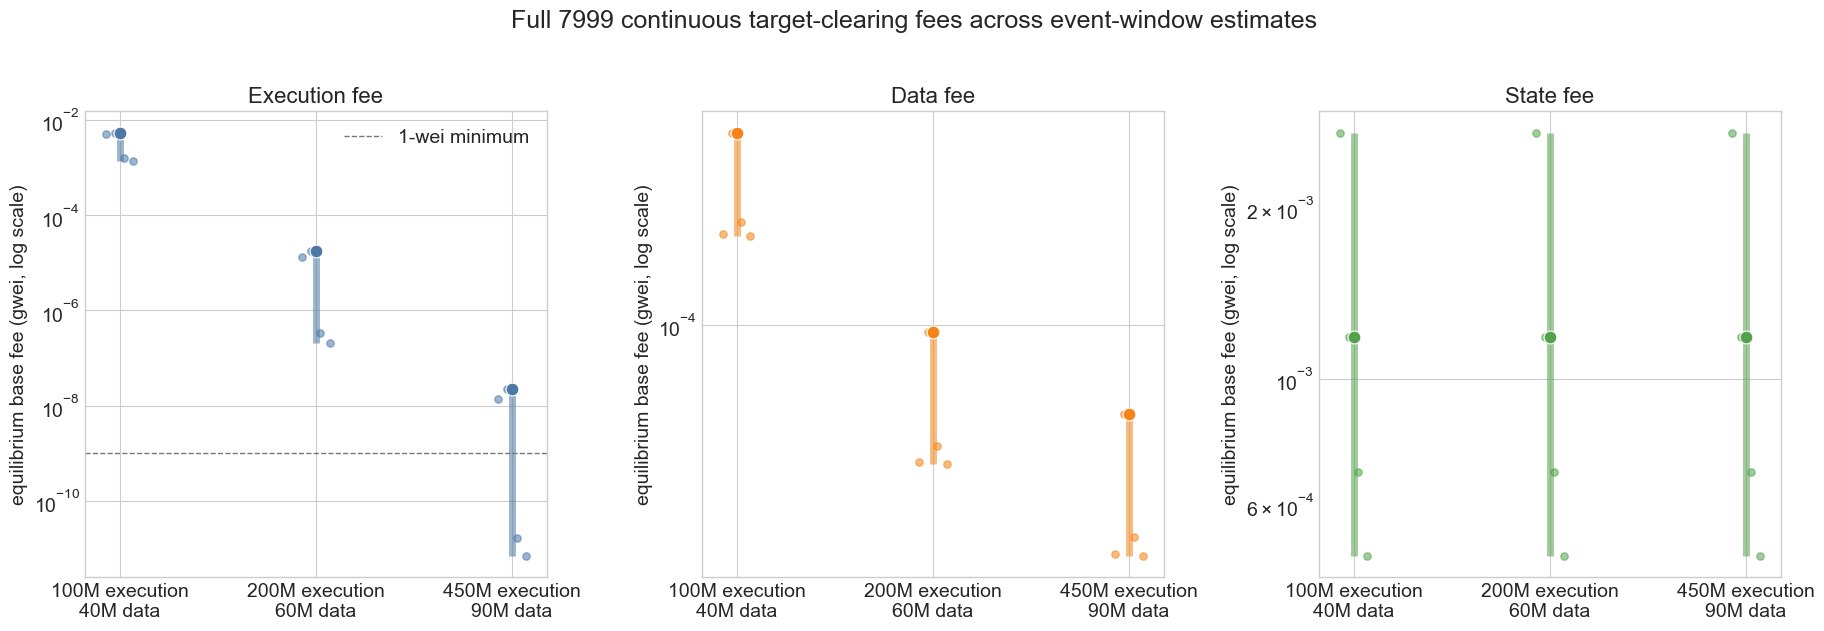

In [7]:
window_rows = results[results["paired_capacity_scenario"]].copy()
window_table = window_rows.pivot_table(
    index=["scenario", "execution_gas_limit", "data_gas_limit", "window_days"],
    columns="resource", values="equilibrium_base_fee_gwei", aggfunc="first",
).reset_index().rename(columns={
    "execution": "execution_base_fee_gwei",
    "data": "data_base_fee_gwei",
    "state": "state_base_fee_gwei",
})
window_export_cols = [
    "scenario", "execution_gas_limit", "data_gas_limit",
    "window_days", "resource", "gas_target", "elasticity",
    "equilibrium_base_fee_wei_continuous", "equilibrium_base_fee_gwei",
    "protocol_base_fee_wei", "protocol_target_error_pct",
    "protocol_fee_at_minimum", "static_data_gas_at_equilibrium",
    "bal_data_gas_at_equilibrium", "bal_share_of_data_target",
    "execution_access_proxy_ratio_to_anchor", "state_physical_ratio_to_anchor",
    "bal_parent_activity_ratio", "bal_state_creation_weight", "bal_price_elasticity",
]
window_rows[window_export_cols].sort_values(
    ["scenario", "window_days", "resource"]
).to_csv(OUT_WINDOW_CSV, index=False)
display(window_table)

RESOURCE_COLORS = {"execution": "#4C78A8", "data": "#F58518", "state": "#54A24B"}
paired_order = ["E100_D40_S75", "E200_D60_S75", "E450_D90_S75"]
paired_labels = [
    "100M execution\n40M data",
    "200M execution\n60M data",
    "450M execution\n90M data",
]
fig, axes = plt.subplots(1, 3, figsize=(18.5, 6.2), sharex=True)
for ax, resource in zip(axes, RESOURCES):
    resource_rows = window_rows[window_rows["resource"].eq(resource)]
    for x_pos, scenario in enumerate(paired_order):
        values = resource_rows[resource_rows["scenario"].eq(scenario)].set_index("window_days")["equilibrium_base_fee_gwei"]
        central_value = float(values.loc[CENTRAL_WINDOW])
        ax.vlines(x_pos, values.min(), values.max(), color=RESOURCE_COLORS[resource], alpha=0.55, linewidth=5)
        jitter = np.linspace(-0.07, 0.07, len(values))
        ax.scatter(x_pos + jitter, values.values, color=RESOURCE_COLORS[resource], alpha=0.55, s=28)
        ax.scatter(x_pos, central_value, color=RESOURCE_COLORS[resource], edgecolor="white", linewidth=0.8, s=85, zorder=4)
    if resource == "execution":
        ax.axhline(MIN_BASE_FEE_WEI / GWEI, color="#777777", linestyle="--", linewidth=1, label="1-wei minimum")
        ax.legend(fontsize=14)
    ax.set_yscale("log")
    ax.set_xticks(range(len(paired_order)), paired_labels)
    ax.set_title(f"{resource.capitalize()} fee")
    ax.set_ylabel("equilibrium base fee (gwei, log scale)")
fig.suptitle("Full 7999 continuous target-clearing fees across event-window estimates", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / f"full_7999_equilibrium_window_sensitivity_{DATE_LABEL}.png", dpi=160, bbox_inches="tight")
plt.show()

## Strict Direct State-Creation BAL Linkage

Notebook 1.11 supplies one strict direct-entry estimate for the share of BAL bytes linked to newly created storage slots, accounts, and code. Ambiguous balance and nonce changes remain with execution/existing-state access.

The baseline BAL is partitioned between execution/state-access activity and persistent state creation, with weights summing to one. The direct BAL response to the data fee remains fixed at $\gamma_{\mathrm{BAL}}=0$.


In [8]:
display(bal_coupling_card[[
    "role", "state_creation_weight", "execution_state_access_weight",
    "bootstrap_ci_2_5", "bootstrap_ci_97_5", "sample_blocks", "sample_days",
]])


,role,state_creation_weight,execution_state_access_weight,bootstrap_ci_2_5,bootstrap_ci_97_5,sample_blocks,sample_days
0,strict_direct_entries,0.132676,0.867324,0.124803,0.141094,1200,120


## Interpretation And Next Step

- Full 7999 has an equilibrium **fee vector**, not one equilibrium base fee. Execution and state retain independent target-clearing equations, while the data condition includes static content plus induced BAL gas.
- Notebook 1.11 finds under the strict direct-entry definition that about 13.0% of BAL bytes are linked to newly created storage slots, accounts, and code. The other 87.0% consists of reads, existing-state writes, and account activity, so it remains attached to execution/state-access activity.
- Total execution quantity is still only a reduced-form proxy for the missing state-access index. That proxy—not the size of the state-linked slice—is now the main coupling limitation.
- The 3-by-3 execution/data capacity grid separates execution-limit effects from propagation-derived data limits. The paired 100M/40M, 200M/60M, and 450M/90M cases are selected summaries.
- The data metering bridge removes the EIP-7623 floor, then exposes each static addition. Uniform 16-gas byte accounting is used for calldata, blob hashes, access lists, and authorization tuples.
- The full-sample 120-day calibration produces 0.08846 BAL gas per historical regular-execution gas, or about 5.53 kB of BAL payload per million execution gas. Notebook 1.11 partitions that baseline BAL without assigning an entire state-creating transaction to the state resource.
- We set $\gamma_{\mathrm{BAL}}=0$. BAL demand changes through its parent quantities, not through an invented static-data elasticity.
- Execution uses the full-sample 120-day EIP-8038 + EIP-2780 refund-corrected multiplier from notebook 1.10. State clears a 75M target with no hard limit.
- At sufficiently large targets, the continuous execution target-clearing fee can fall below the 1-wei protocol minimum. The window table reports the theoretical fee and nearest represented protocol fee.
- Reserve pricing, explicit state-access demand, full transaction-resource price coupling, limit hits, fee volatility, and shock recovery remain outside this steady-state notebook.
